# Step 1: Load Libraries and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Layer, Permute, multiply, concatenate
from tensorflow.keras.callbacks import EarlyStopping
import math

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# Load the dataset (replace with your actual path)
try:
    df = pd.read_csv('T1.csv')
except FileNotFoundError:
    print("Please ensure 'T1.csv' is in the same directory.")
    exit()

In [4]:
# Display initial info
print("Initial DataFrame Info:")
df.info()

Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


# Step 2: Prepare the Data

In [7]:
# Convert 'Date/Time' to datetime objects
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format="%d %m %Y %H:%M", errors='coerce')
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format="%d %m %Y %H:%M", errors='coerce')
df.set_index('Date/Time', inplace=True)
# Select relevant features
features = ['LV ActivePower (kW)', 'Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)']
data = df[features]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create a separate scaler for the target variable to inverse transform later
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(data[['LV ActivePower (kW)']])

print("\nScaled Data Shape:", scaled_data.shape)



Scaled Data Shape: (50530, 3)


# Step 3: Create Sequences

In [8]:

def create_sequences(data, seq_length):
    """
    Creates sequences of data for the RNN.
    
    Args:
        data (np.ndarray): The normalized data.
        seq_length (int): The length of the input sequence.
        
    Returns:
        tuple: (X, y) sequences.
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])  # Assuming 'LV ActivePower (kW)' is the first column
    return np.array(X), np.array(y)

# Define sequence length and create the sequences
seq_length = 24  # 24 hours of data
X, y = create_sequences(scaled_data, seq_length)

print("\nSequence Data Shapes:")
print("X shape:", X.shape)
print("y shape:", y.shape)



Sequence Data Shapes:
X shape: (50506, 24, 3)
y shape: (50506,)


# Step 4: Split the data

In [9]:
# Split ratio
split_ratio = 0.8
split_index = int(split_ratio * len(X))

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("\nTraining and Testing Data Shapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


Training and Testing Data Shapes:
X_train shape: (40404, 24, 3)
y_train shape: (40404,)
X_test shape: (10102, 24, 3)
y_test shape: (10102,)


# Step 5: Define a custom attention layer

In [10]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], input_shape[-1]),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[-1],),
                                 initializer="zeros", trainable=True)
        self.u = self.add_weight(name="att_context", shape=(input_shape[-1],),
                                 initializer="glorot_uniform", trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # Alignment scores
        u_t = tf.tanh(tf.matmul(x, self.W) + self.b)
        
        # Attention weights
        a = tf.nn.softmax(tf.reduce_sum(self.u * u_t, axis=-1, keepdims=True))

        # Context vector
        context_vector = tf.reduce_sum(a * x, axis=1)
        
        return context_vector, a

    def get_config(self):
        return super(Attention, self).get_config()

# Step 6: Build the RNN Model with attention

In [11]:
# Model parameters
lstm_units = 64
dropout_rate = 0.2

# Functional API model
input_layer = Input(shape=(seq_length, X_train.shape[2]))
lstm_output = LSTM(lstm_units, return_sequences=True)(input_layer)
dropout_1 = Dropout(dropout_rate)(lstm_output)

# Use the custom Attention layer
context_vector, attention_weights = Attention()(dropout_1)

# Pass the context vector to the dense layer
dense_1 = Dense(lstm_units, activation='relu')(context_vector)
dropout_2 = Dropout(dropout_rate)(dense_1)
output_layer = Dense(1)(dropout_2)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Print the model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ [(None, 64), (None,    │         4,224 │
│                                 │ 24, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

# Step 7: Compile and Train the Model

In [12]:
# Set up EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0698 - val_loss: 0.0128
Epoch 2/50
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0217 - val_loss: 0.0118
Epoch 3/50
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0189 - val_loss: 0.0104
Epoch 4/50
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0166 - val_loss: 0.0112
Epoch 5/50
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0143 - val_loss: 0.0083
Epoch 6/50
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0133 - val_loss: 0.0083
Epoch 7/50
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0121 - val_loss: 0.0069
Epoch 8/50
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0112 - val_loss: 0.0082
Epoch 9/50
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0104 - val_loss: 0.0062
Epoch 10/50
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0100 - val_loss: 0.0062
Epoch 11/50
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0094 - val_loss: 0.0066
Epoch 12/50
1137/1137 

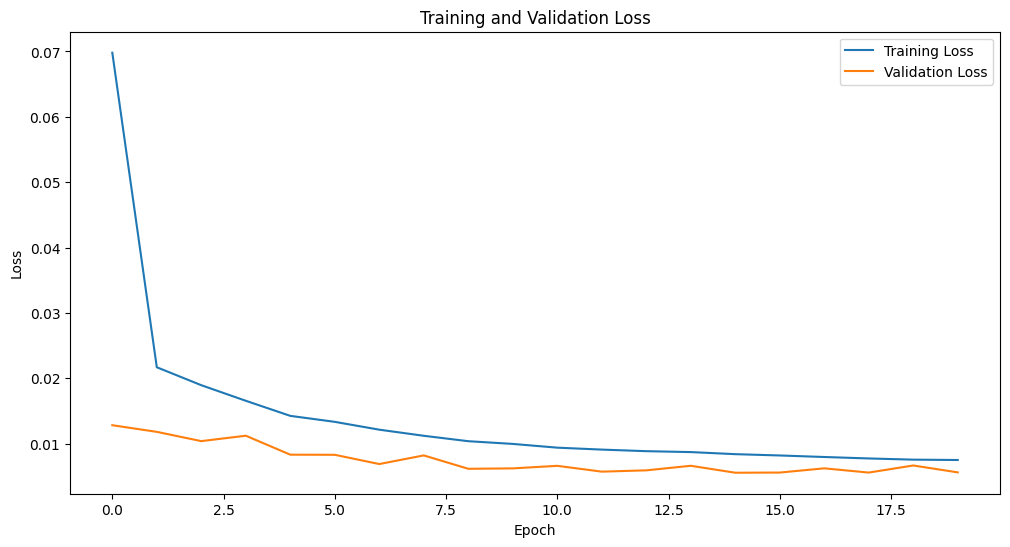

In [13]:
# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Step 8: Evaluate and visualize the results

In [14]:
# Generate predictions on the test set
y_pred_scaled = model.predict(X_test)

316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [15]:
# Inverse transform predictions and actual values to original scale
y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_original = target_scaler.inverse_transform(y_pred_scaled)

In [16]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred_original)

print("\nModel Evaluation on Test Data:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.4f}")



Model Evaluation on Test Data:
Mean Squared Error (MSE): 59635.96
Root Mean Squared Error (RMSE): 244.20
R-squared (R²): 0.9669


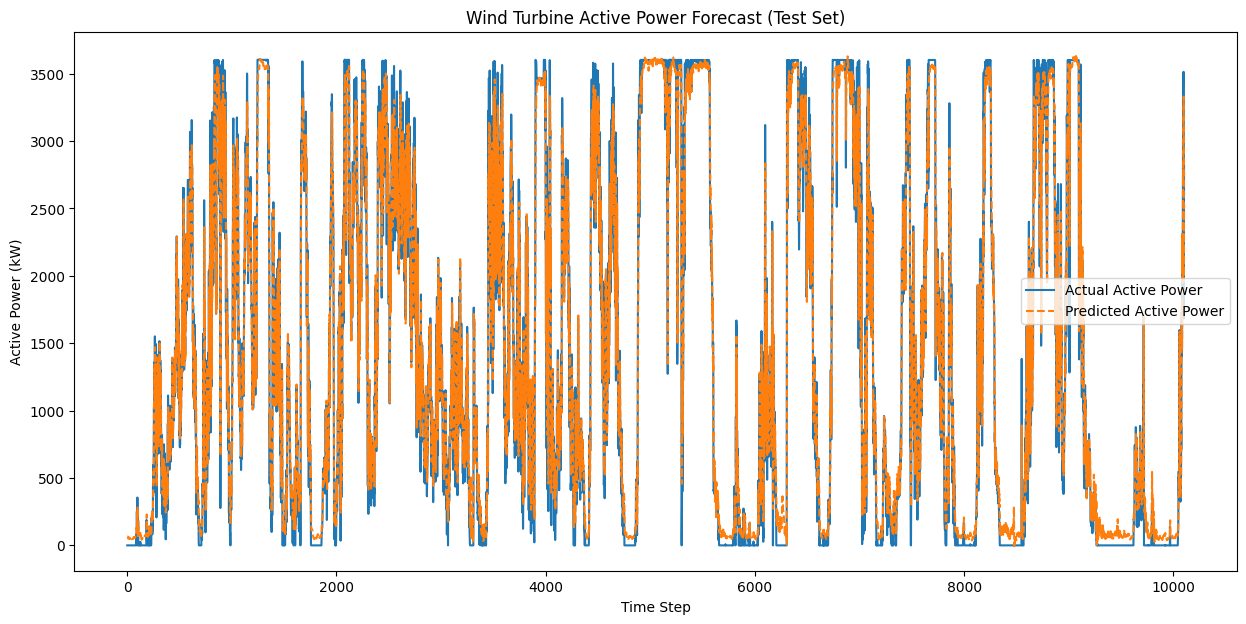

In [17]:
# Plot predicted vs. actual values (time-series)
plt.figure(figsize=(15, 7))
plt.plot(y_test_original, label='Actual Active Power')
plt.plot(y_pred_original, label='Predicted Active Power', linestyle='--')
plt.title('Wind Turbine Active Power Forecast (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Active Power (kW)')
plt.legend()
plt.show()

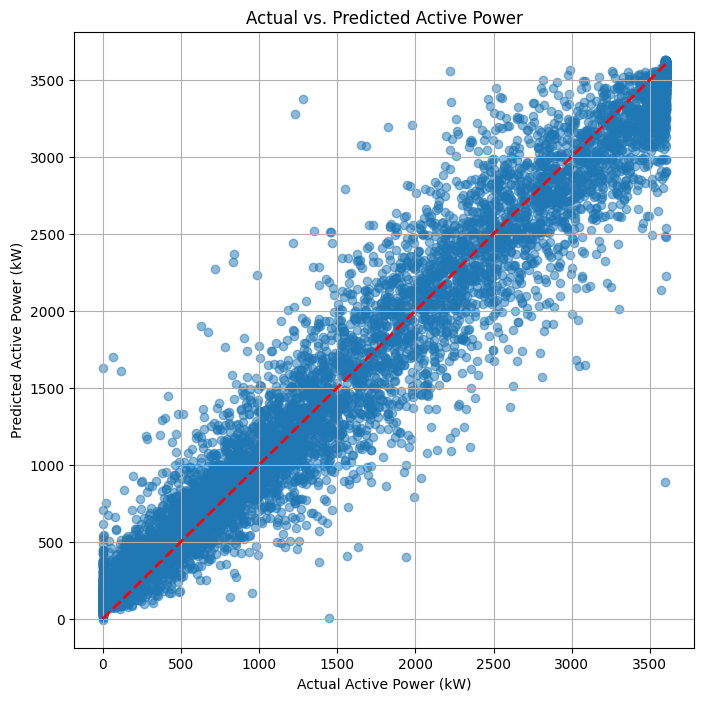

In [18]:
# Plot scatter plot of predicted vs. actual values
plt.figure(figsize=(8, 8))
plt.scatter(y_test_original, y_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2)
plt.title('Actual vs. Predicted Active Power')
plt.xlabel('Actual Active Power (kW)')
plt.ylabel('Predicted Active Power (kW)')
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


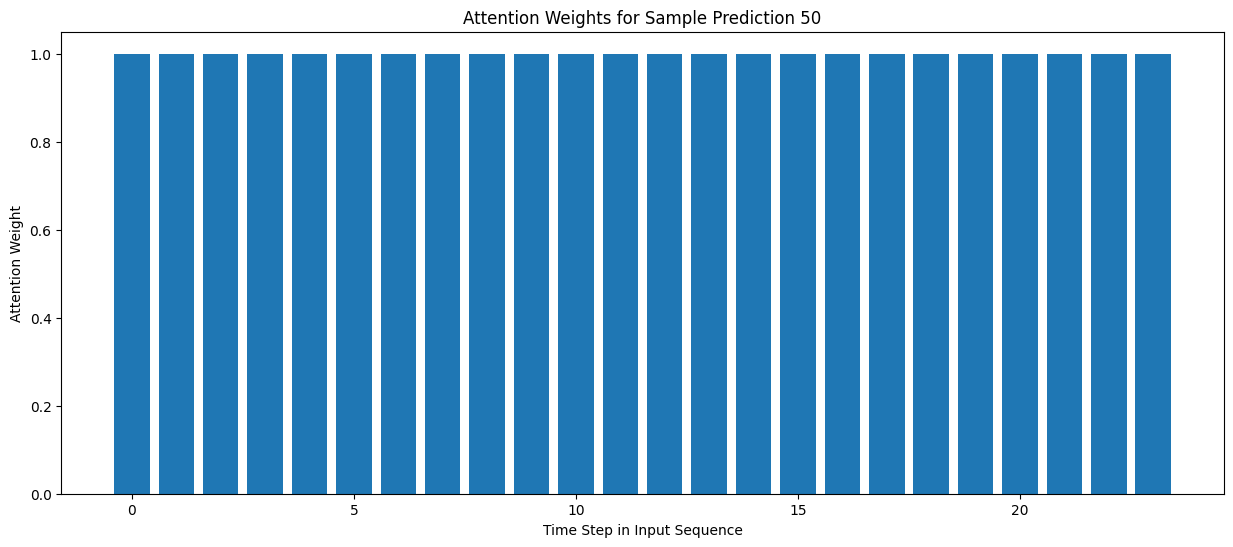


Predicted Power for Sample 50: 48.03 kW
Actual Power for Sample 50: 0.00 kW


In [21]:
# Visualize attention weights for a sample prediction
sample_idx = 50
sample_input = X_test[sample_idx:sample_idx+1]

# Rebuild model to get attention weights as a separate output
attention_model = Model(inputs=model.input, outputs=[model.output, attention_weights])
y_pred_sample, attention_weights_sample = attention_model.predict(sample_input)

# Extract attention weights
attention_weights_sample = attention_weights_sample.flatten()

# Plot attention weights
plt.figure(figsize=(15, 6))
plt.bar(range(seq_length), attention_weights_sample)
plt.title(f'Attention Weights for Sample Prediction {sample_idx}')
plt.xlabel('Time Step in Input Sequence')
plt.ylabel('Attention Weight')
plt.show()

print(f"\nPredicted Power for Sample {sample_idx}: {y_pred_original[sample_idx][0]:.2f} kW")
print(f"Actual Power for Sample {sample_idx}: {y_test_original[sample_idx][0]:.2f} kW")